# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [4]:
import pandas as pd

df = pd.read_csv('loan_data.csv')

df.head(25)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1
5,22,male,Bachelor,70130.700025,6,MORTGAGE,9008.104188,VENTURE,12.575501,0.128447,22,770.974257,No,0
6,41,female,Associate,86965.993882,11,OWN,23398.537788,EDUCATION,11.770607,0.269054,19,596.305523,No,1
7,72,female,Associate,60412.931964,6,MORTGAGE,24495.392501,PERSONAL,9.146556,0.405466,19,734.020668,No,0
8,21,male,Bachelor,77241.160427,25,RENT,17674.382881,DEBTCONSOLIDATION,14.211276,0.228821,22,653.042056,No,0
9,49,male,Doctorate,57373.429325,4,OWN,14848.496412,PERSONAL,12.188035,0.258804,26,738.978230,No,1


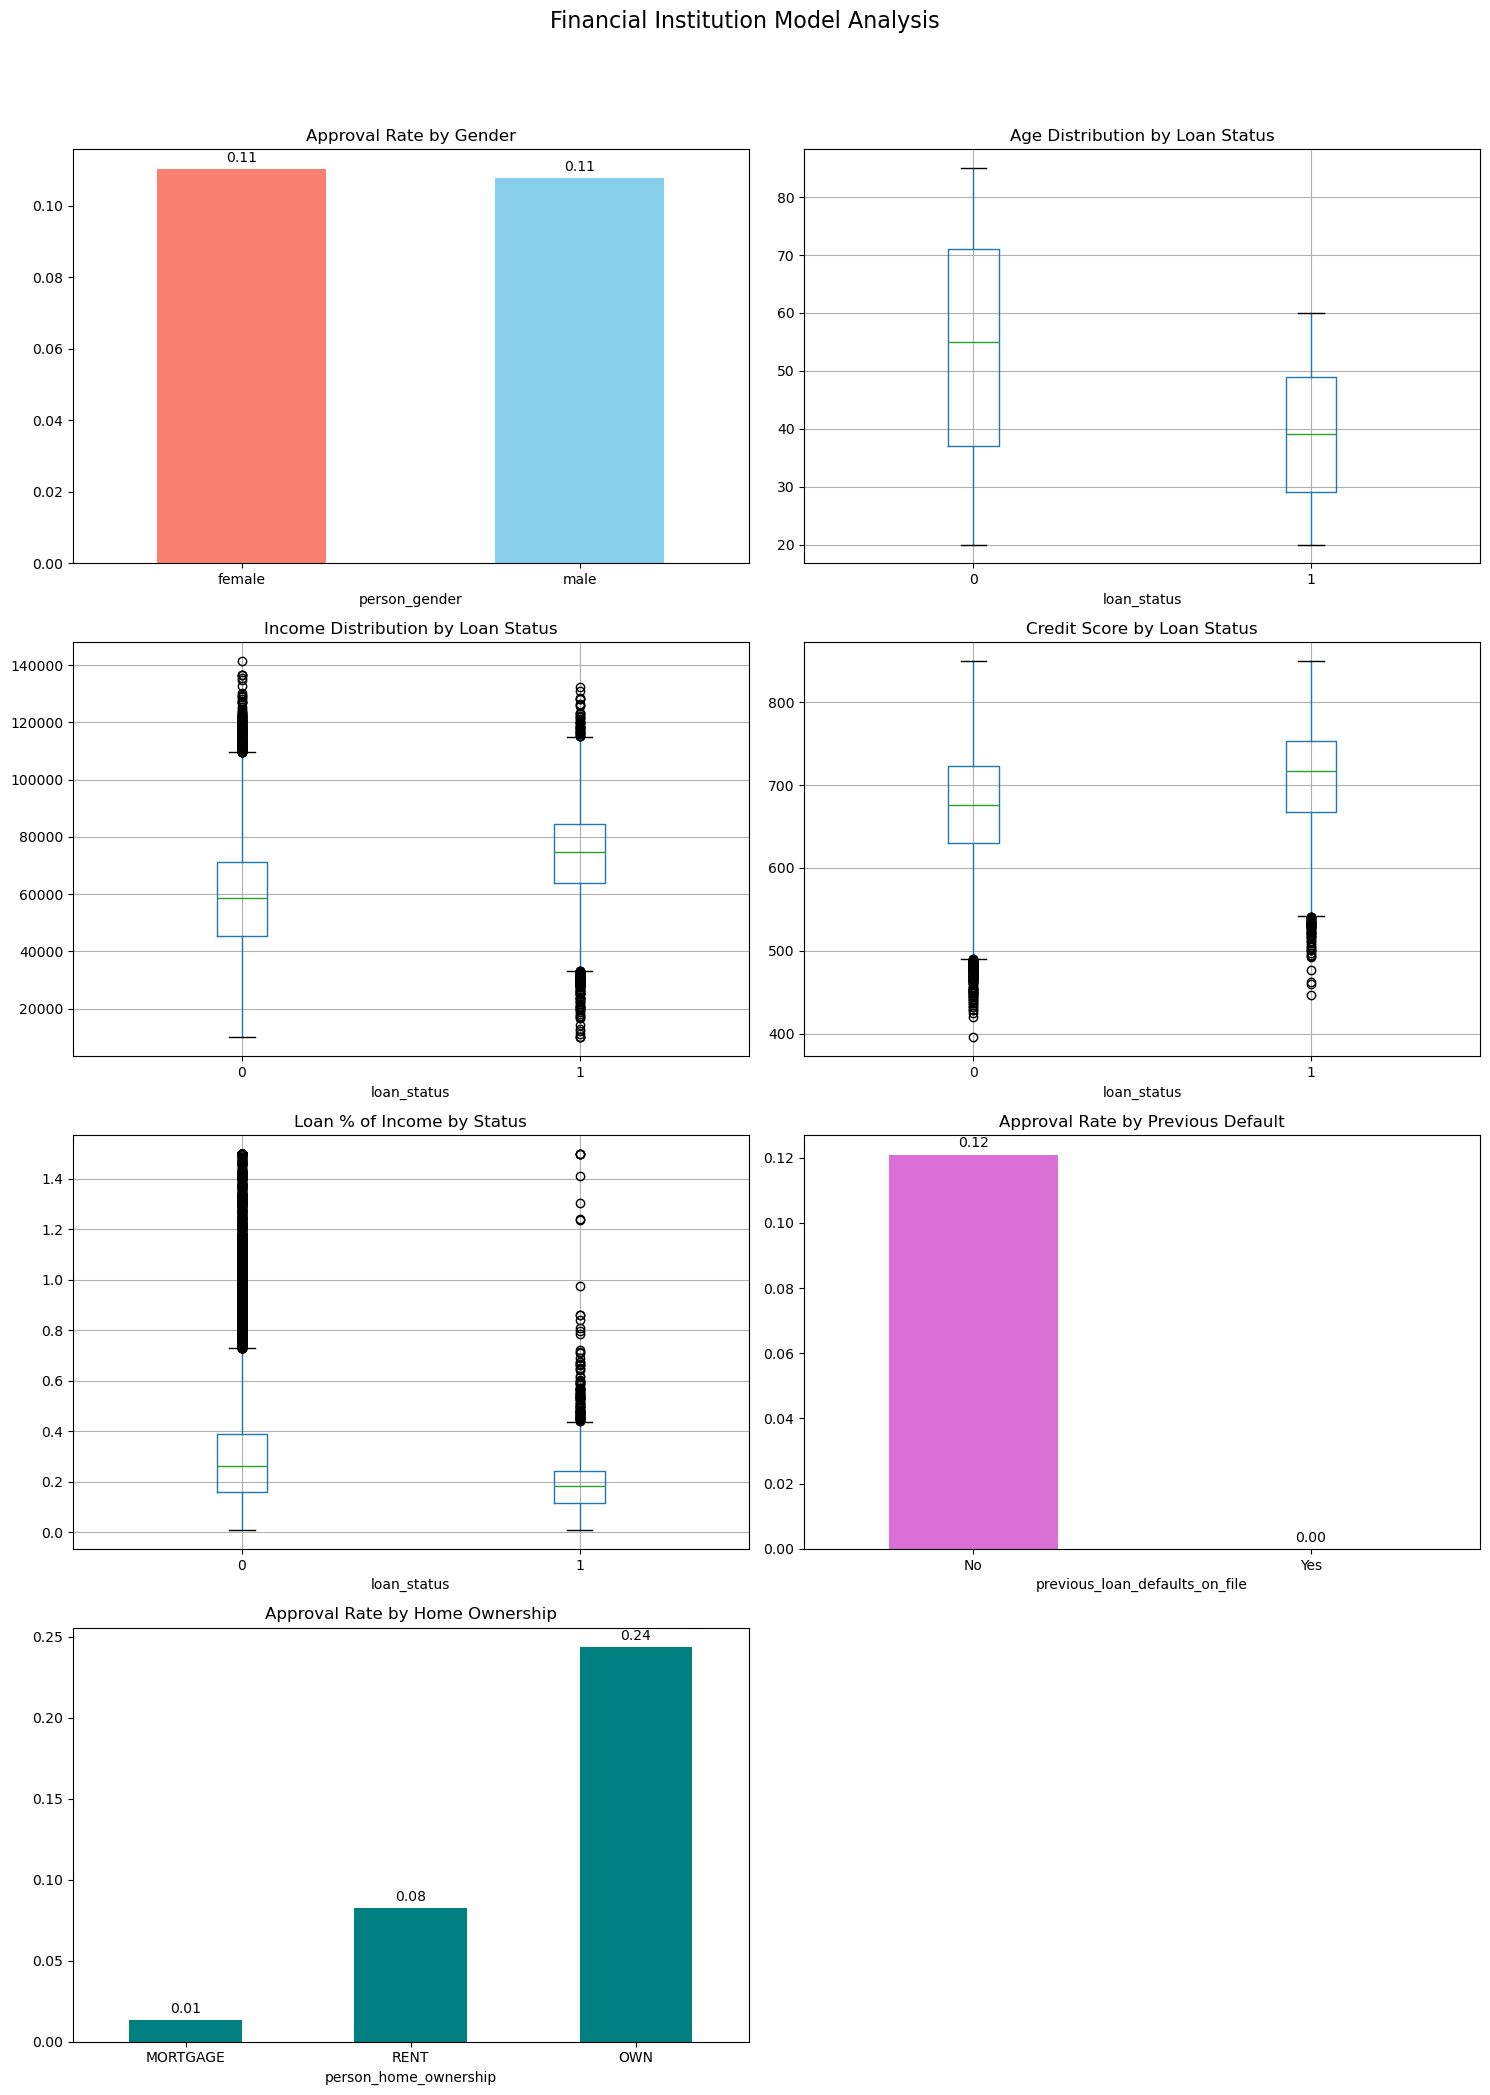

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a 4x2 grid (8 slots for 7 features + 1 empty)
fig, axes = plt.subplots(4, 2, figsize=(15, 22))
axes = axes.flatten()

# --- 1. GENDER (Categorical) ---
df.groupby('person_gender')['loan_status'].mean().plot(kind='bar', ax=axes[0], color=['salmon', 'skyblue'])
axes[0].bar_label(axes[0].containers[0], fmt='%.2f', padding=3)
axes[0].set_title('Approval Rate by Gender')
axes[0].tick_params(axis='x', rotation=0)

# --- 2. AGE (Quantitative - BOXPLOT) ---
df.boxplot(column='person_age', by='loan_status', ax=axes[1])
axes[1].set_title('Age Distribution by Loan Status')

# --- 3. INCOME (Quantitative - BOXPLOT) ---
df.boxplot(column='person_income', by='loan_status', ax=axes[2])
axes[2].set_title('Income Distribution by Loan Status')

# --- 4. CREDIT SCORE (Quantitative - BOXPLOT) ---
df.boxplot(column='credit_score', by='loan_status', ax=axes[3])
axes[3].set_title('Credit Score by Loan Status')

# --- 5. LOAN PERCENT INCOME (Quantitative - BOXPLOT) ---
df.boxplot(column='loan_percent_income', by='loan_status', ax=axes[4])
axes[4].set_title('Loan % of Income by Status')

# --- 6. PREVIOUS DEFAULTS (Categorical) ---
df.groupby('previous_loan_defaults_on_file')['loan_status'].mean().plot(kind='bar', ax=axes[5], color='orchid')
axes[5].bar_label(axes[5].containers[0], fmt='%.2f', padding=3)
axes[5].set_title('Approval Rate by Previous Default')
axes[5].tick_params(axis='x', rotation=0)

# --- 7. HOME OWNERSHIP (Categorical) ---
df.groupby('person_home_ownership')['loan_status'].mean().sort_values().plot(kind='bar', ax=axes[6], color='teal')
axes[6].bar_label(axes[6].containers[0], fmt='%.2f', padding=3)
axes[6].set_title('Approval Rate by Home Ownership')
axes[6].tick_params(axis='x', rotation=0)

# Remove the empty 8th subplot
fig.delaxes(axes[7])

plt.suptitle('Financial Institution Model Analysis', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [6]:
# Check the total count of the data
print(f"Total applicants: {len(df)}")

# Check the actual count of approvals vs rejections
print(df['loan_status'].value_counts())

Total applicants: 45000
loan_status
0    40107
1     4893
Name: count, dtype: int64


# Understanding the Model's Decision Pathing
- Unfortunately for the financier, the model does indeed descriminate-- just not about gender. The approval of loans based on age drastically reduces distribution the higher age goes-- chiefly above 50 years of age.
- More significantly to the model's true nature, the % of income status and income distribution shows a MASSIVE outlier group where majority are seeking 140% of their annual earning potential.
- In addition, the median credit score for loan approval is SIGNIFICANTLY higher than disapproval. This, in tandem with the preference against high risk 1.4+ outliers suggests a goal of low risk loans.
- Home ownership is arguably one of the strongest modifiers for whether a loan is approved, while a history of prior defaults is effectively an automatic decline. Renting a home comes with low odds of approval, and a mortgage even lower.
# Unrelated Datapoints
- Contrary to the raised concern from the applicants, the model is completely neutral on gender with an EXACT 1:1 ratio of acceptance.
# Concern over Legal Trouble
Yes, the model owner should be concerned about legal ramifications due to age descrimination. They risk angering powerful lifetime moguls and tycoons by making it difficult to acquire a loan if applying under their own name but above the age of 50, with the further outliers being as high as 80. These people must have fair access regardless of age. More significantly, this is a direct violation of fair lending practices.